# Predicting subsurface eddy tilt from surface signatures

This notebook tests whether surface properties contain predictive information about subsurface eddy tilt. It is a feasibility and generalisation experiment, not an attempt to fill unknown observations.

The primary safeguards are:

- predict eastward and northward tilt components rather than regressing directly on a circular bearing;
- run completely separate AE and CE experiments;
- keep all observations from an eddy in the same data partition;
- compare nonlinear and linear models with a mean-vector baseline;
- evaluate displacement-vector, distance, and circular-direction errors separately;
- calculate feature importance only on eddies excluded from fitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt
import ml_subsurface_tools as ml

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42

## 1. Load the surface and tilt data

`add_pv_gradient_terms(..., core_mean=True)` calculates the shallow-water PV-gradient vector using core-mean bathymetry and bathymetric gradients. The workflow uses its magnitude (`PV_grad_mag`) and converts its compass bearing (`PV_grad_theta`) into eastward and northward vector components. This preserves both the magnitude–magnitude and direction–direction relationships with tilt.

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)

df_eddies, df_tilt = tilt.load_tilt_tables(paths)
df_vert = tilt.load_vert(paths)

max_depth = (
    df_vert.groupby(["Eddy", "Day"], as_index=False)["Depth"]
    .max()
    .rename(columns={"Depth": "max_profile_depth"})
)

df_eddies = df_eddies.merge(
    max_depth,
    on=["Eddy", "Day"],
    how="inner",
)

df_eddies = df_eddies[
    df_eddies["max_profile_depth"] > 850
].copy()

df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)
df_eddies = tilt.add_time_coordinates(df_eddies)
print(f"Rows: {len(df_eddies):,}")
print(f"Unique eddies: {df_eddies['Eddy'].nunique():,}")

df_eddies["PV_grad_east"] = df_eddies["PV_grad_x"]
df_eddies["PV_grad_north"] = df_eddies["PV_grad_y"]
df_eddies[ml.FEATURES + ["TiltDis", "TiltDir"]].head()

Rows: 88,199
Unique eddies: 2,793


,lat,beta,f,h,w,Omega,Rc,AR,norm_time,PV_grad_mag,PV_grad_east,PV_grad_north,TiltDis,TiltDir
0,-38.866383,-1.808336e-11,-0.000091,NaN,-0.000032,-0.000013,29.449052,1.973172,0.000000,NaN,NaN,NaN,NaN,NaN
1,-38.814279,-1.809818e-11,-0.000091,NaN,-0.000041,-0.000017,29.449052,1.859668,0.043478,NaN,NaN,NaN,NaN,NaN
2,-38.816261,-1.809204e-11,-0.000091,NaN,-0.000035,-0.000015,32.090160,1.745185,0.086957,NaN,NaN,NaN,NaN,NaN
3,-38.902070,-1.807290e-11,-0.000092,4712.428834,-0.000020,-0.000009,34.827275,1.433213,0.130435,8.269894e-15,-3.022524e-15,-7.697760e-15,19.823350,87.507772
4,-38.935135,-1.806988e-11,-0.000092,4705.411335,-0.000026,-0.000013,37.564389,1.140614,0.173913,1.195343e-14,-8.609373e-16,-1.192239e-14,15.055658,105.302388


### Target-definition checkpoint

Before interpreting model skill, confirm that `TiltDis` and `TiltDir` describe tilt over the same vertical interval for every eddy-day. If the terminal depth varies, absolute distance also represents vertical-profile length. In that case, repeat the analysis with tilt to a fixed depth or with tilt distance divided by vertical separation.

The above is accounted for ^^

## 2. Audit target availability and prepare the modelling table

Missing tilt values may not be random. Coverage is reported overall and by polarity before complete cases are selected. Conclusions from the model apply to eddy-days for which a valid tilt was calculated.

In [3]:
coverage = ml.target_availability_summary(df_eddies)
coverage

,rows,valid_tilt_rows,valid_fraction,eddies,eddies_with_tilt
group,,,,,
All,88199,79390,0.900124,2793,2745
AE,42658,38935,0.912724,1319,1284
CE,45541,40455,0.888320,1474,1461


In [4]:
model_df = ml.prepare_modelling_table(df_eddies)
polarity_data = {cyc: model_df[model_df["Cyc"] == cyc].copy() for cyc in ("AE", "CE")}

print(f"Complete modelling rows: {len(model_df):,}")
print(f"Independent eddy groups: {model_df['Eddy'].nunique():,}")
print(f"Retained fraction: {len(model_df) / len(df_eddies):.1%}")
pd.DataFrame({
    cyc: {"rows": len(part), "eddies": part["Eddy"].nunique()}
    for cyc, part in polarity_data.items()
}).T

Complete modelling rows: 79,390
Independent eddy groups: 2,745
Retained fraction: 90.0%


,rows,eddies
AE,38935,1284
CE,40455,1461


Both `TiltDir` and `PV_grad_theta` are compass bearings (0° north, 90° east). The tilt targets are therefore

```text
TiltEast  = TiltDis × sin(TiltDir)
TiltNorth = TiltDis × cos(TiltDir)
```

The PV-gradient predictors are encoded in the same coordinate system:

```text
PV_grad_east  = PV_grad_mag × sin(PV_grad_theta)
PV_grad_north = PV_grad_mag × cos(PV_grad_theta)
```

The model therefore receives PV-gradient magnitude plus its two vector components. Tilt distance and bearing are reconstructed after prediction. This makes 359° and 1° neighbouring directions rather than opposite numerical extremes.

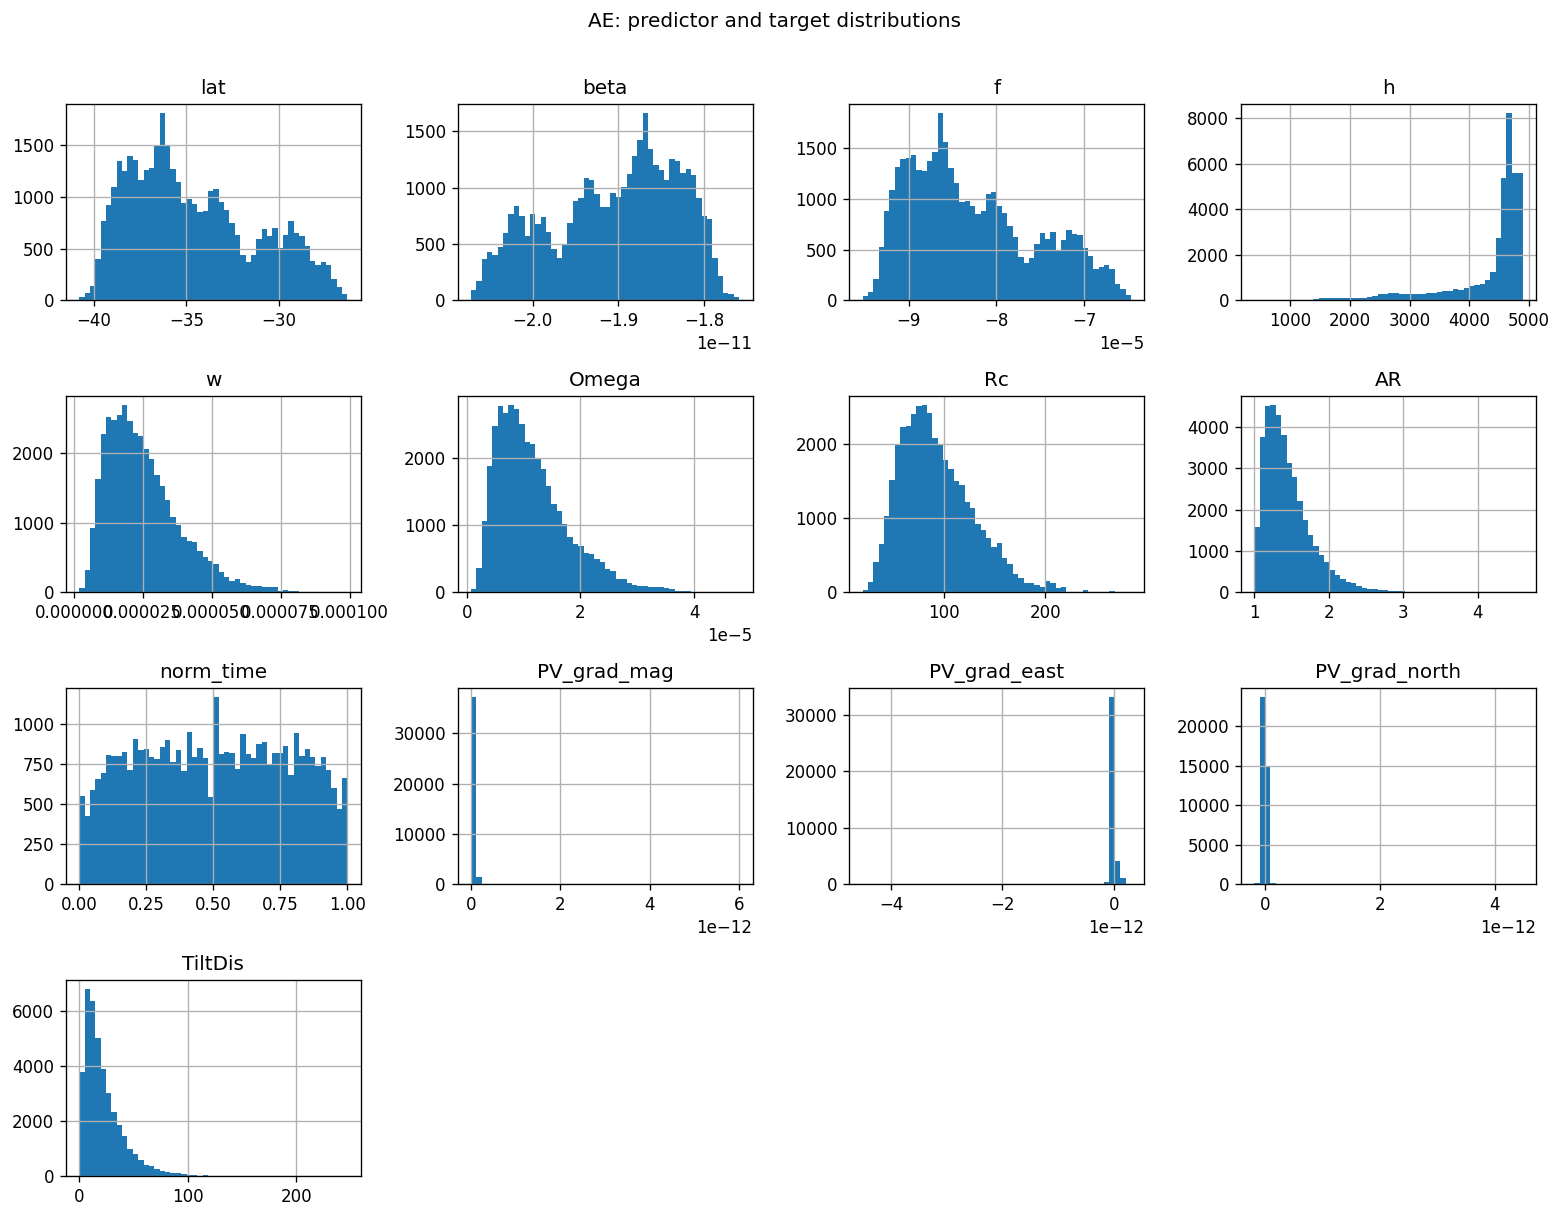

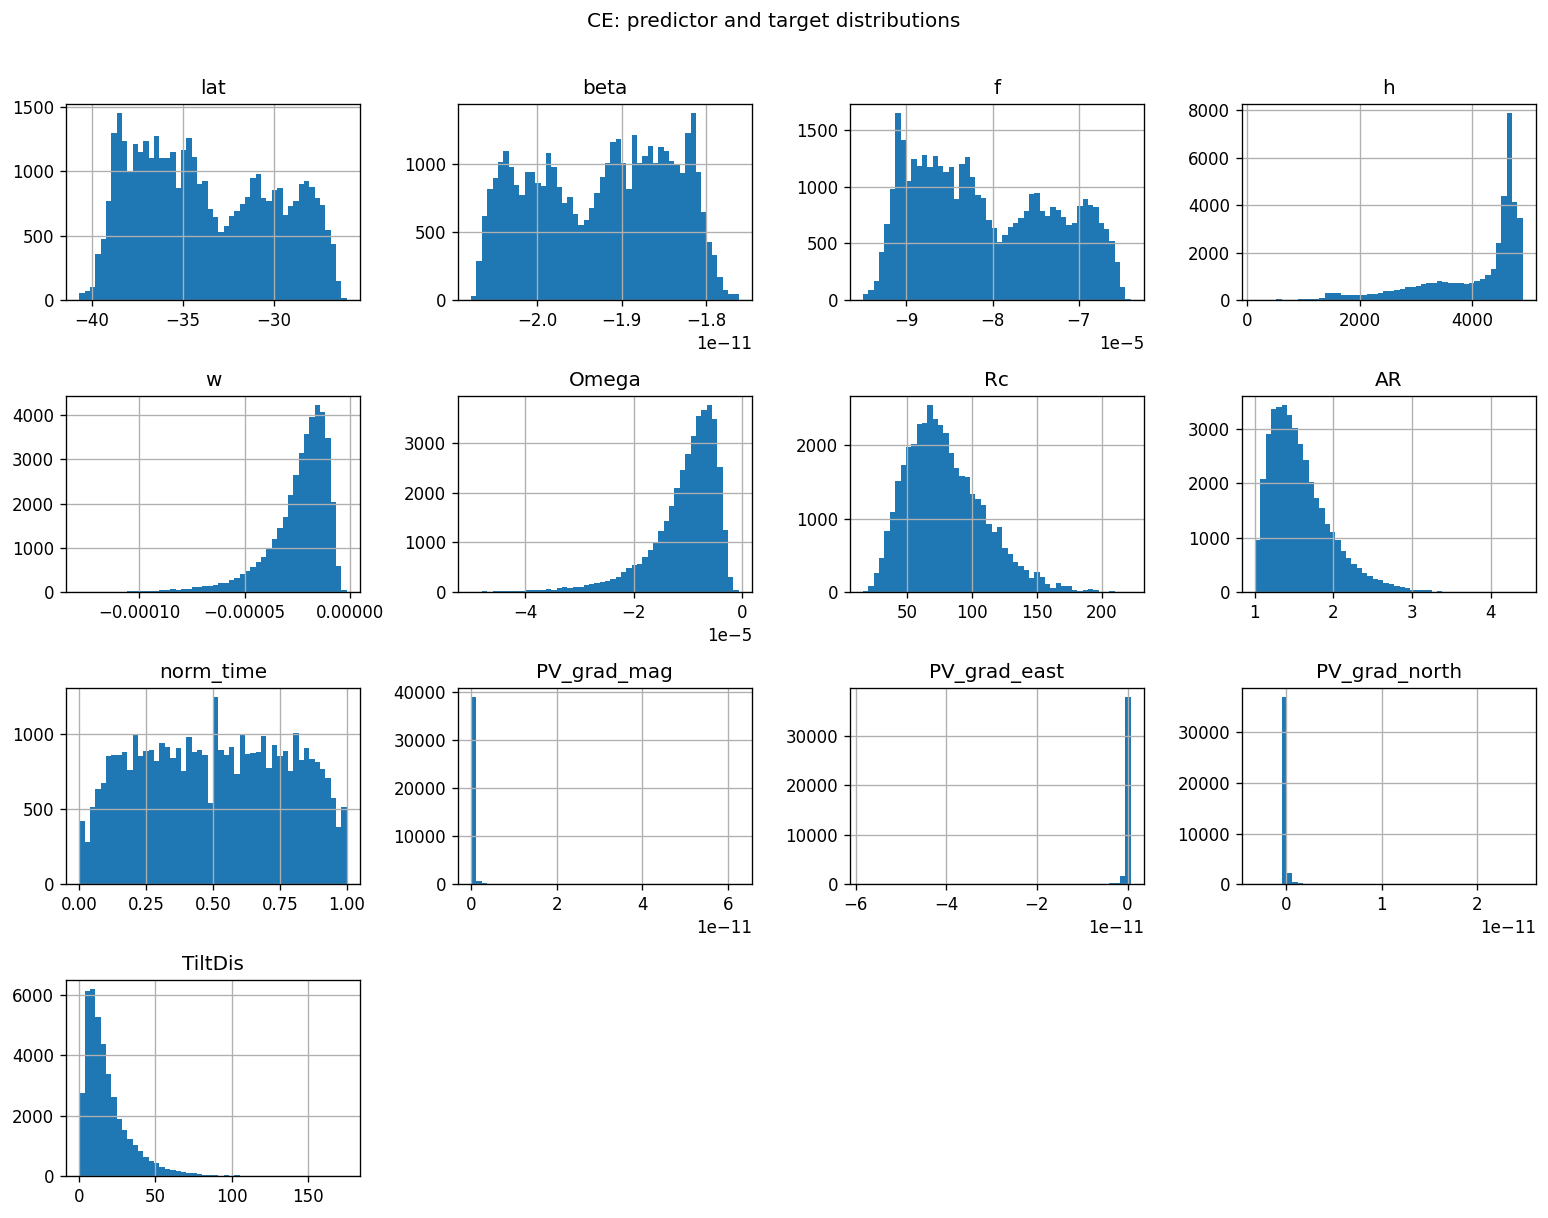

In [5]:
for cyc, part in polarity_data.items():
    part[ml.NUMERIC_FEATURES + ["TiltDis"]].hist(bins=50, figsize=(13, 10))
    plt.suptitle(f"{cyc}: predictor and target distributions", y=1.01)
    plt.tight_layout()

### Observed PV-gradient relationships

These panels inspect the two relationships motivating inclusion of the complete PV-gradient vector: gradient magnitude against tilt magnitude, and the circular difference between gradient and tilt direction. AE and CE are shown separately. They are descriptive only; grouped validation below determines whether the relationships generalise to unseen eddies.

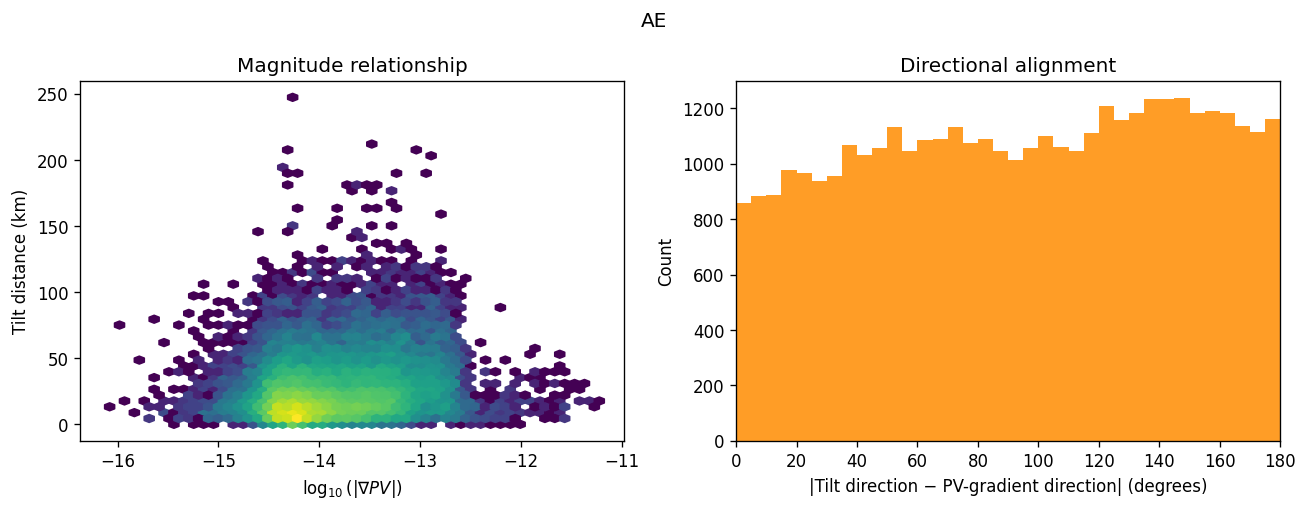

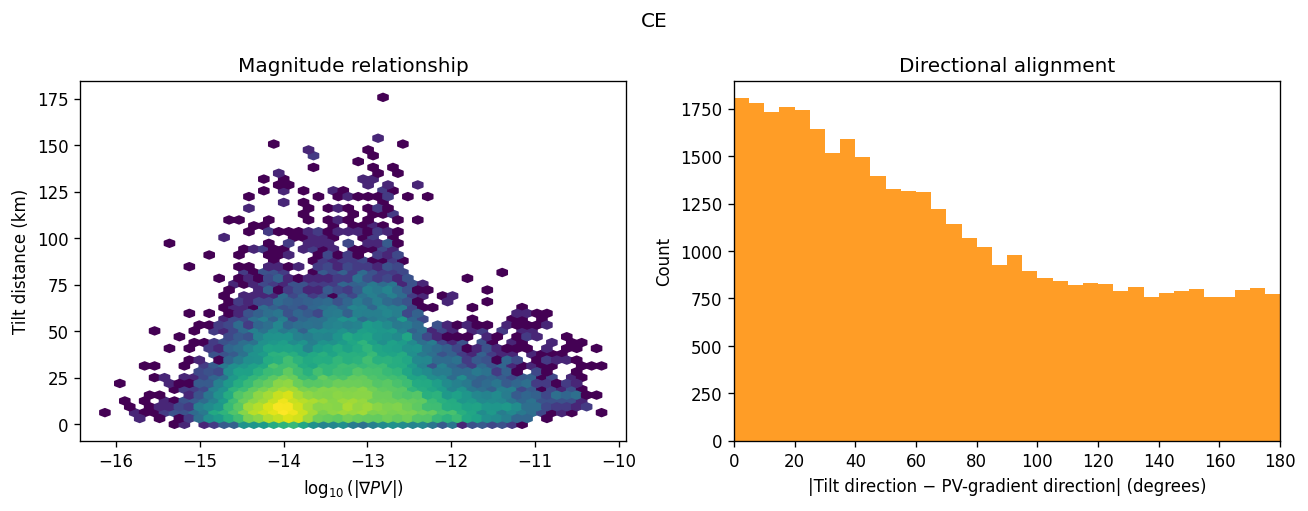

In [6]:
for cyc, part in polarity_data.items():
    valid_pv = part[["PV_grad_mag", "PV_grad_theta", "TiltDis", "TiltDir"]].dropna()
    valid_pv = valid_pv[valid_pv["PV_grad_mag"] > 0]
    pv_tilt_angle = ml.angular_error_deg(valid_pv["TiltDir"], valid_pv["PV_grad_theta"])
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
    axes[0].hexbin(np.log10(valid_pv["PV_grad_mag"]), valid_pv["TiltDis"],
                   gridsize=50, mincnt=1, bins="log", cmap="viridis")
    axes[0].set(xlabel=r"$\log_{10}(|\nabla PV|)$", ylabel="Tilt distance (km)",
                title="Magnitude relationship")
    axes[1].hist(pv_tilt_angle, bins=np.arange(0, 185, 5), color="darkorange", alpha=0.85)
    axes[1].set(xlabel="|Tilt direction − PV-gradient direction| (degrees)",
                ylabel="Count", xlim=(0, 180), title="Directional alignment")
    fig.suptitle(cyc)
    plt.tight_layout()

## 3. Hold out complete eddies

A random row split would leak adjacent days from the same eddy into training and testing. Within each polarity, `GroupShuffleSplit` holds out 20% of eddy identities. AE and CE never share models, preprocessors, baselines, or fitted parameters.

In [7]:
splits = {
    cyc: ml.grouped_train_test_split(part, test_size=0.20, random_state=RANDOM_STATE)
    for cyc, part in polarity_data.items()
}

split_summary = []
for cyc, split in splits.items():
    assert set(split.groups_train).isdisjoint(set(split.groups_test))
    split_summary.append({
        "Cyc": cyc, "training rows": len(split.X_train), "test rows": len(split.X_test),
        "training eddies": split.groups_train.nunique(), "test eddies": split.groups_test.nunique(),
    })
pd.DataFrame(split_summary).set_index("Cyc")

,training rows,test rows,training eddies,test eddies
Cyc,,,,
AE,31407,7528,1027,257
CE,31964,8491,1168,293


## 4. Fit baseline, linear, and nonlinear models

The predictors are exactly:

```python
['lat', 'w', 'Omega', 'Rc', 'AR', 'norm_time',
 'PV_grad_mag', 'PV_grad_east', 'PV_grad_north']
```

`norm_time` is the observation's position through its eddy lifetime: 0 at the first observed day and 1 at the final observed day. `Age` is not used. AE and CE are fitted independently, so `Cyc` is not a predictor. `PV_grad_east` and `PV_grad_north` preserve direction. `PV_grad_mag` is retained because Ridge cannot reconstruct the nonlinear magnitude `sqrt(east² + north²)` from linear component terms; permutation importance tests whether it adds held-out predictive information. `Rc` is used rather than `R`.

In [8]:
experiments = {}
for cyc, split in splits.items():
    models = ml.build_models(random_state=RANDOM_STATE)
    fitted = ml.fit_models(models, split)
    scores, predictions = ml.evaluate_models(fitted, split)
    experiments[cyc] = {"models": models, "fitted": fitted,
                        "scores": scores, "predictions": predictions}

pd.concat({cyc: result["scores"] for cyc, result in experiments.items()},
          names=["Cyc", "model"]).round(3)

vector_MAE_km  vector_RMSE_km  distance_MAE_km  \
Cyc model                                                                  
AE  Ridge                        22.342          28.980           15.444   
    Mean-vector baseline         22.760          29.581           16.339   
    Gradient boosting            22.843          29.565           14.995   
CE  Gradient boosting            17.642          23.188           11.766   
    Ridge                        17.798          23.454           13.466   
    Mean-vector baseline         18.488          24.179           14.465   

                          distance_RMSE_km  east_R2  north_R2  \
Cyc model                                                       
AE  Ridge                           23.141    0.047     0.034   
    Mean-vector baseline            24.669   -0.000    -0.001   
    Gradient boosting               22.380    0.030    -0.026   
CE  Gradient boosting               17.716    0.071     0.083   
    Ridge                           20.132    0.054     0.057   
    Mean-vector baseline            21.248   -0.000    -0.006   

                          median_angular_error_deg  within_30deg_fraction  \
Cyc model                                                                   
AE  Ridge                                   55.323                  0.297   
    Mean-vector baseline                    58.760                  0.279   
    Gradient boosting                       55.656                  0.303   
CE  Gradient boosting                       49.486                  0.345   
    Ridge                                   51.674                  0.321   
    Mean-vector baseline                    55.945                  0.313   

                          within_45deg_fraction  
Cyc model                                        
AE  Ridge                                 0.425  
    Mean-vector baseline                  0.403  
    Gradient boosting                     0.425  
CE  Gradient boosting                     0.467  
    Ridge                                 0.452  
    Mean-vector baseline                  0.429

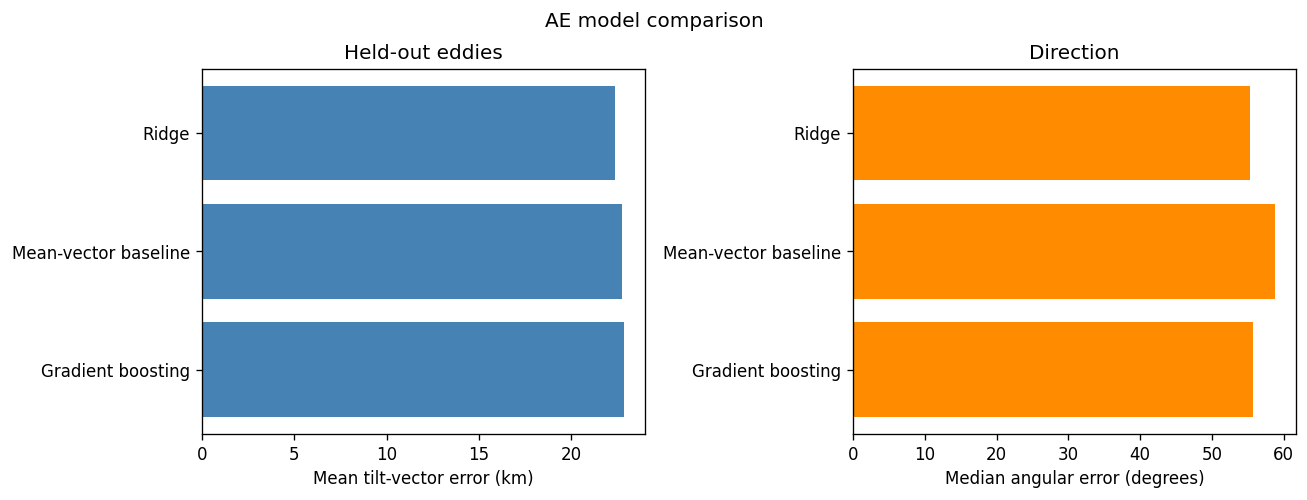

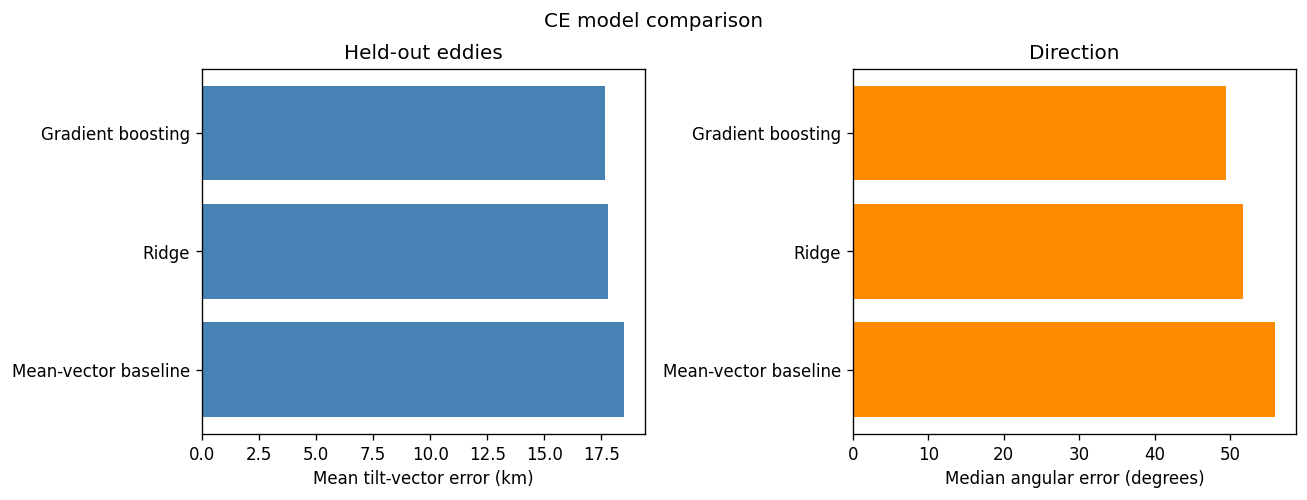

In [9]:
for cyc, result in experiments.items():
    fig, axes = ml.plot_model_comparison(result["scores"])
    fig.suptitle(f"{cyc} model comparison", y=1.03)

The primary metric is mean displacement-vector error because it jointly penalises distance and direction. Distance MAE measures magnitude skill. Angular error is reported separately, but should not dominate interpretation when observed tilt is close to zero and its direction is physically unstable. A useful model must improve materially on the mean-vector baseline on unseen eddies.

## 5. Diagnose the best predictive model

AE best candidate: Ridge
CE best candidate: Gradient boosting


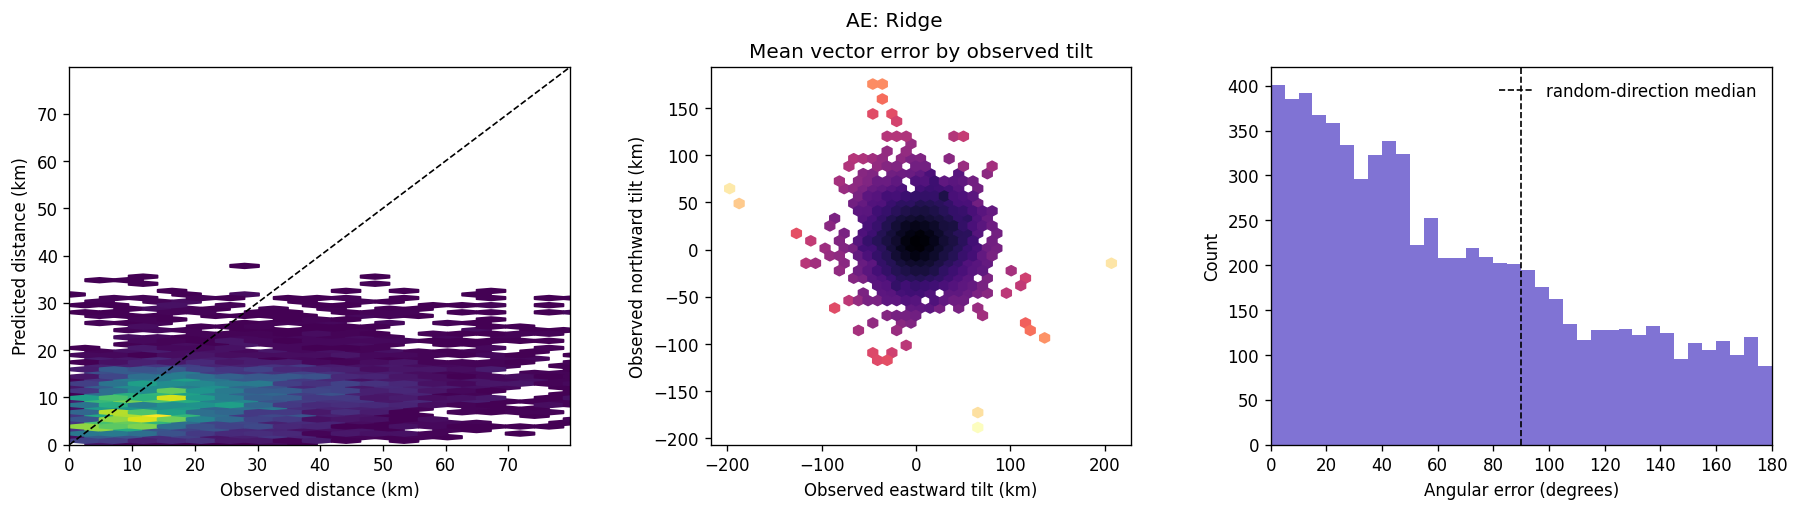

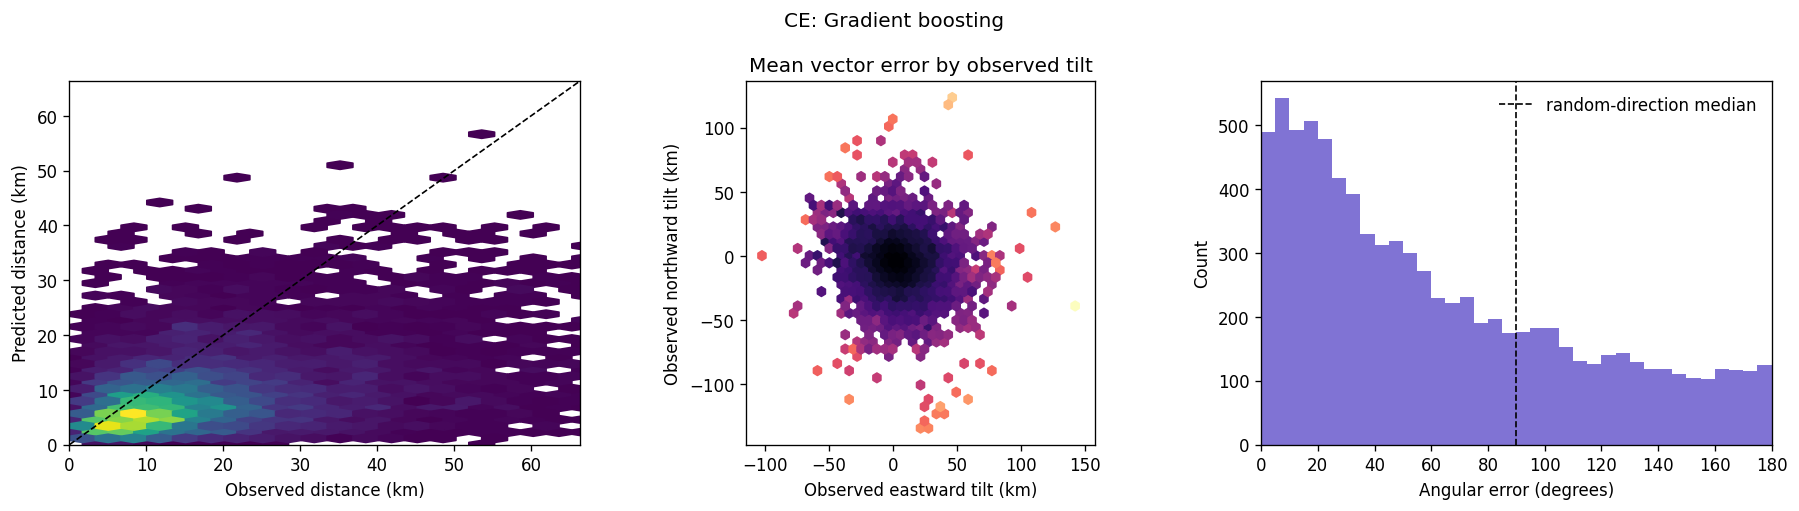

In [10]:
for cyc, result in experiments.items():
    candidate_scores = result["scores"].drop(index="Mean-vector baseline", errors="ignore")
    result["best_name"] = candidate_scores["vector_MAE_km"].idxmin()
    result["best_prediction"] = result["predictions"][result["best_name"]]
    print(f"{cyc} best candidate: {result['best_name']}")
    ml.plot_prediction_diagnostics(result["best_prediction"],
                                   title=f"{cyc}: {result['best_name']}");

Direction is ill-defined for very small displacement. The next table repeats circular metrics after imposing progressively larger observed-tilt thresholds.

In [11]:
pd.concat({
    cyc: ml.direction_performance_by_tilt(result["best_prediction"], thresholds=(0, 5, 10, 20))
    for cyc, result in experiments.items()
}, names=["Cyc", "minimum_tilt_km"]).round(3)

rows  median_angular_error_deg  within_30deg_fraction  \
Cyc minimum_tilt_km                                                          
AE  0                7528                    55.323                  0.297   
    5                6857                    52.518                  0.309   
    10               5700                    50.090                  0.321   
    20               3460                    46.779                  0.349   
CE  0                8491                    49.486                  0.345   
    5                7565                    47.808                  0.358   
    10               5824                    45.554                  0.371   
    20               2954                    43.684                  0.385   

                     within_45deg_fraction  
Cyc minimum_tilt_km                         
AE  0                                0.425  
    5                                0.440  
    10                               0.455  
    20                               0.482  
CE  0                                0.467  
    5                                0.479  
    10                               0.494  
    20                               0.510

All results above and below are generated by separate polarity-specific workflows. The next table simply collects their held-out scores side by side; it does not evaluate a combined model.

In [12]:
pd.concat({cyc: result["scores"] for cyc, result in experiments.items()},
          names=["Cyc", "model"])[[
    "vector_MAE_km", "distance_MAE_km",
    "median_angular_error_deg", "within_30deg_fraction",
]].round(3)

vector_MAE_km  distance_MAE_km  \
Cyc model                                                  
AE  Ridge                        22.342           15.444   
    Mean-vector baseline         22.760           16.339   
    Gradient boosting            22.843           14.995   
CE  Gradient boosting            17.642           11.766   
    Ridge                        17.798           13.466   
    Mean-vector baseline         18.488           14.465   

                          median_angular_error_deg  within_30deg_fraction  
Cyc model                                                                  
AE  Ridge                                   55.323                  0.297  
    Mean-vector baseline                    58.760                  0.279  
    Gradient boosting                       55.656                  0.303  
CE  Gradient boosting                       49.486                  0.345  
    Ridge                                   51.674                  0.321  
    Mean-vector baseline                    55.945                  0.313

## 6. Grouped cross-validation

Five-fold grouped cross-validation is run independently within AE and CE. Each polarity refits both models five times, and no eddy appears in both training and validation within a fold. This cell can take several minutes.

In [13]:
cv_results = pd.concat({
    cyc: ml.grouped_cross_validation(result["models"], polarity_data[cyc], n_splits=5)
    for cyc, result in experiments.items()
}, names=["Cyc", "row"]).reset_index(level=0)
cv_summary = cv_results.groupby(["Cyc", "model"]).agg(
    vector_MAE_mean=("vector_MAE_km", "mean"),
    vector_MAE_std=("vector_MAE_km", "std"),
    distance_MAE_mean=("distance_MAE_km", "mean"),
    angular_error_median=("median_angular_error_deg", "median"),
    within_30deg_mean=("within_30deg_fraction", "mean"),
)
cv_summary.round(3)

vector_MAE_mean  vector_MAE_std  distance_MAE_mean  \
Cyc model                                                                   
AE  Gradient boosting           21.565           0.784             13.950   
    Ridge                       21.116           0.861             14.733   
CE  Gradient boosting           17.196           0.256             11.428   
    Ridge                       17.559           0.245             12.849   

                       angular_error_median  within_30deg_mean  
Cyc model                                                       
AE  Gradient boosting                55.165              0.309  
    Ridge                            54.131              0.303  
CE  Gradient boosting                48.601              0.330  
    Ridge                            56.207              0.295

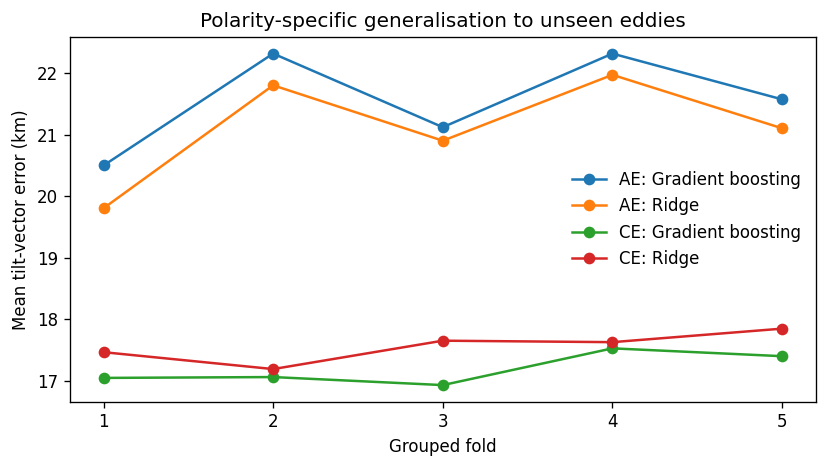

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
for (cyc, name), part in cv_results.groupby(["Cyc", "model"]):
    ax.plot(part["fold"], part["vector_MAE_km"], marker="o", label=f"{cyc}: {name}")
ax.set(xlabel="Grouped fold", ylabel="Mean tilt-vector error (km)", xticks=range(1, 6))
ax.set_title("Polarity-specific generalisation to unseen eddies")
ax.legend(frameon=False)
plt.tight_layout()

## 7. Held-out permutation importance

Each raw predictor is shuffled in the untouched test set. Importance is the resulting increase in mean vector error. This measures predictive reliance, not causality; correlated predictors can share or mask importance.

,feature,importance_mean,importance_std,Cyc
1,beta,19.3808,0.2368,AE
2,f,15.0387,0.2266,AE
4,w,2.6483,0.0764,AE
5,Omega,1.6300,0.0373,AE
0,lat,1.4385,0.0503,AE
8,norm_time,0.2088,0.0104,AE
9,PV_grad_mag,0.1466,0.0178,AE
10,PV_grad_east,0.0606,0.0123,AE
3,h,0.0381,0.0075,AE
11,PV_grad_north,0.0199,0.0072,AE


,feature,importance_mean,importance_std,Cyc
11,PV_grad_north,0.8240,0.0297,CE
10,PV_grad_east,0.6468,0.0345,CE
3,h,0.6160,0.0368,CE
0,lat,0.5093,0.0267,CE
1,beta,0.4559,0.0326,CE
8,norm_time,0.3780,0.0304,CE
9,PV_grad_mag,0.3031,0.0189,CE
6,Rc,0.2947,0.0285,CE
4,w,0.1656,0.0182,CE
5,Omega,0.1159,0.0181,CE


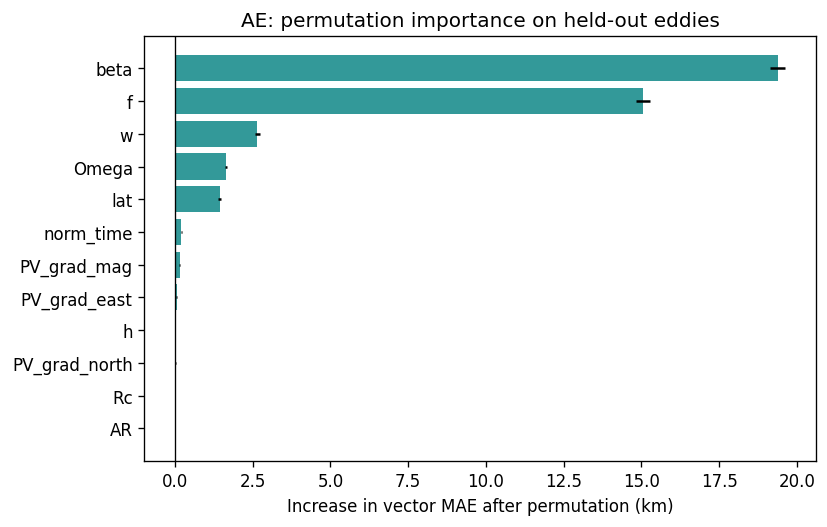

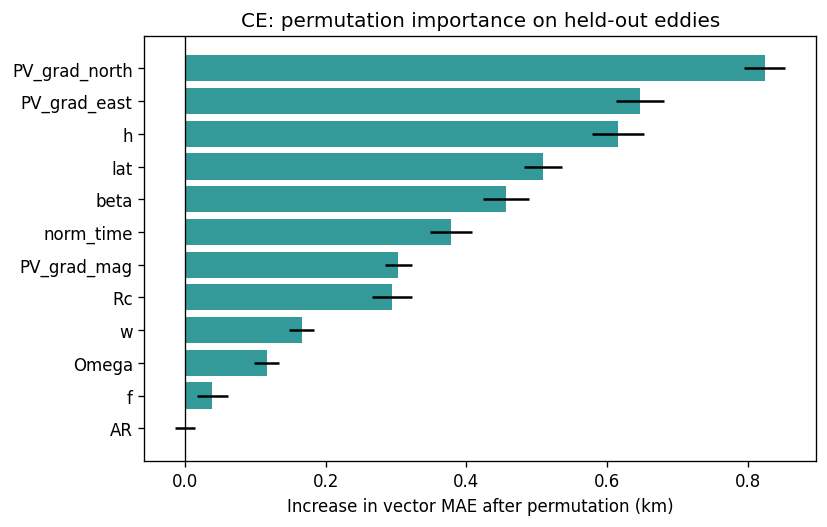

In [15]:
importance_results = {}
for cyc, result in experiments.items():
    split = splits[cyc]
    importance = ml.raw_feature_permutation_importance(
        result["fitted"][result["best_name"]], split.X_test, split.y_test,
        n_repeats=10, random_state=RANDOM_STATE,
    )
    importance_results[cyc] = importance
    display(importance.assign(Cyc=cyc).round(4))
    fig, ax = ml.plot_permutation_importance(importance)
    ax.set_title(f"{cyc}: permutation importance on held-out eddies")

## 8. Interpretation checklist and next experiments

Treat surface-to-tilt prediction as feasible only when the nonlinear and/or linear model improves consistently over the baseline in both the held-out split and grouped folds. Report vector error first, followed by distance and thresholded angular metrics.

Before drawing a physical conclusion:

1. verify that tilt uses a common reference depth;
2. quantify how missing tilt depends on surface predictors separately for AE and CE;
3. compare polarity-specific performance without combining their fitted models;
4. repeat with entire years held out to test temporal transfer;
5. compare this surface-only feature set with a context model containing season, longitude, region, or bathymetry;
6. do not interpret permutation importance as causal evidence.

A useful scientific result can be either positive or negative: strong out-of-eddy skill indicates predictable surface information, while weak skill after leakage-safe validation shows that these surface signatures alone do not constrain instantaneous subsurface tilt sufficiently.